In [1]:
from functools import partial
from mlforecast import MLForecast
from sklearn.linear_model import LinearRegression
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.processing import make_future_dataframe


import os
from functools import partial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
from statsmodels.tsa.seasonal import seasonal_decompose

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import rmse, mae, mape, mase
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

from coreforecast.scalers import boxcox, boxcox_lambda
from utilsforecast.losses import rmse, mae, smape
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import kpss
from statsforecast.models import AutoETS
from statsforecast.arima import ndiffs, nsdiffs
from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA, ARIMA
from statsforecast.arima import ARIMASummary
from copy import deepcopy

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown, Image

from fpppy.utils import plot_series

# endregion 
from plotnine import *

# change working directory 
# Check if current directory has any .ipynb files
if any(fname.endswith(".ipynb") for fname in os.listdir()):
    os.chdir("..")

# load local package modules
from gas_pump_prices.preprocess import * 

%load_ext autoreload
%autoreload 2



# Chapter 10: Dynamic regression models

In normal regression, errors are normally distributed and uncorrelated with each other. In dynamic regression models, errors are modelled with ARIMA() and so can be correlated. To reflect this change in the fundamental structure, $\eta_t$ is used to represent ARIMA errors. 

$$
y_t = \beta_0 + \beta_1 x_{1, t} + ... + \beta_k x_{k, t} + \eta_t
$$

1. Because errors now have autocorrelatiions, parameter estimates cannot be estimated by minimizing sum of squared residuals. This would leave to suboptimal estimates, invalid inferential tests and model fit statistics, and inflated *p* values. Therefore, MLE is used to obtain parameter estimates. 
2. In dynamic regression models, all non-stationary predictors must be rendered stationary (this is known as a model in differences) 
3. If all variables are stationary, then we only need to consider an ARMA process for the errors. 

## 10.2. Regression with ARIMA errors using `StatsForecast`

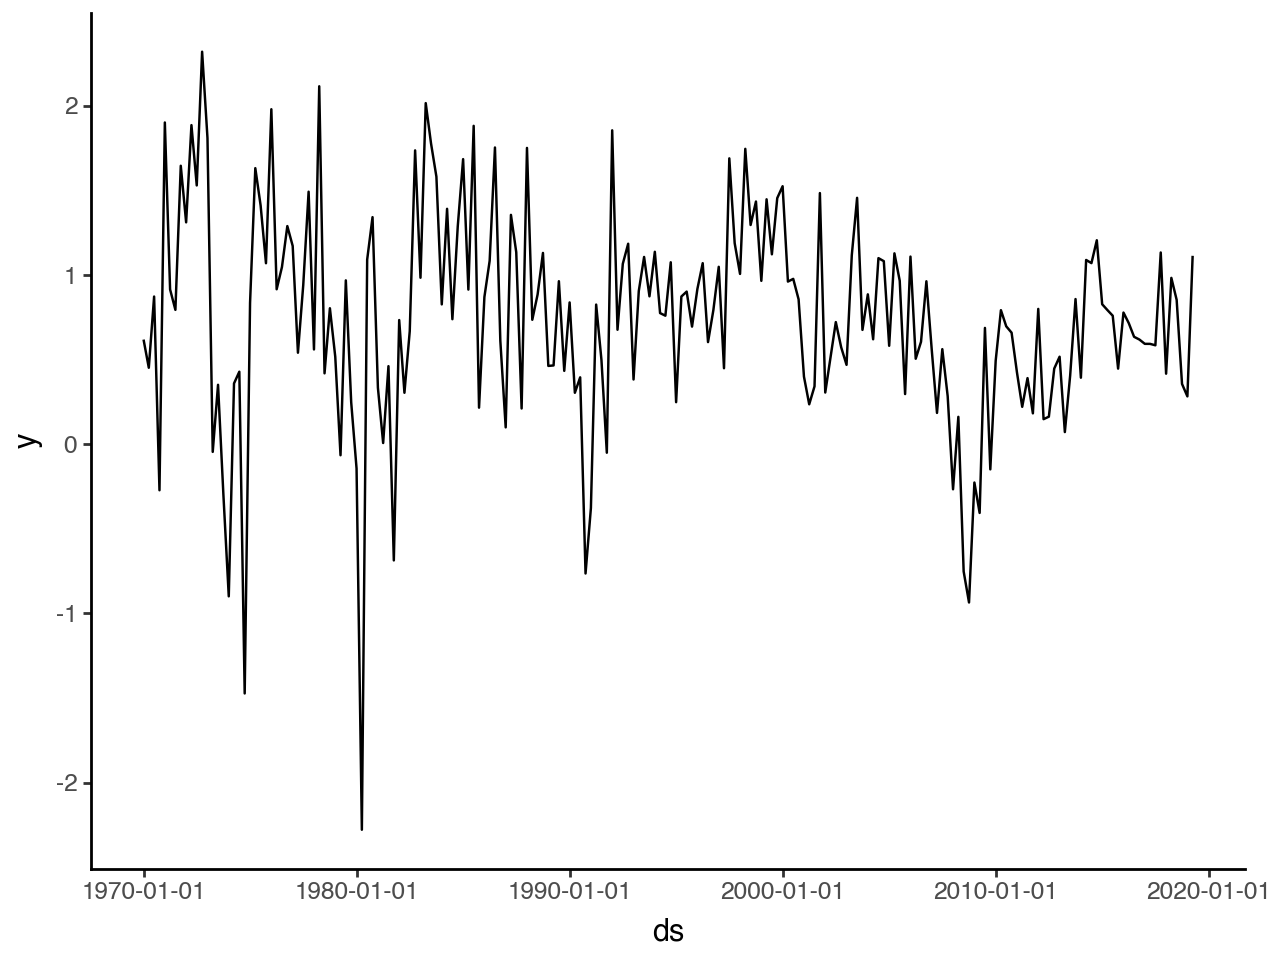

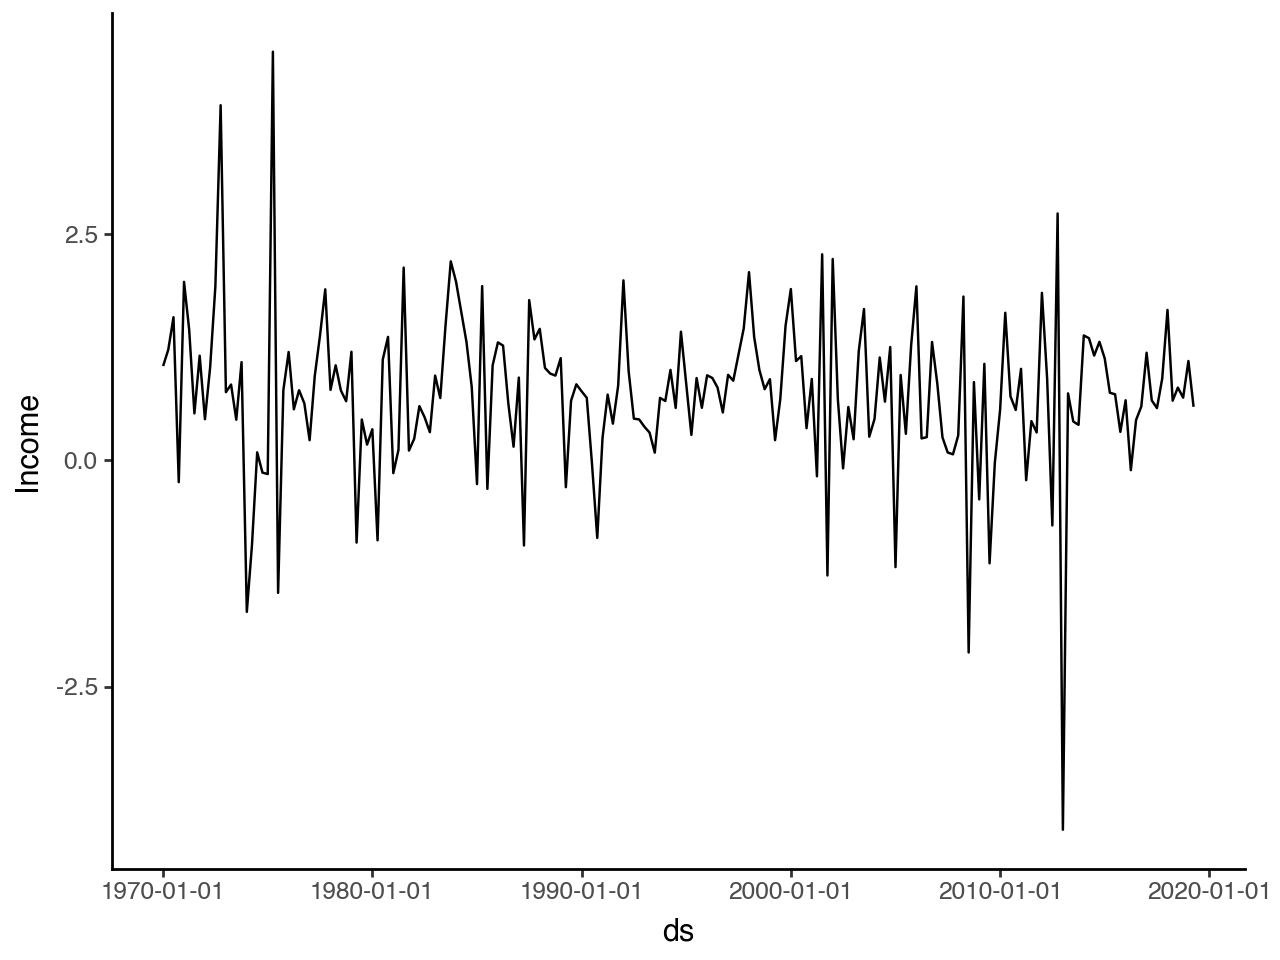

In [3]:
# Example: US personal consumption and income 
df_cons = pd.read_csv('data/raw/US_change.csv', parse_dates=['ds'])
df_cons.rename(columns={"Consumption": "y"}, inplace=True)

# plot consumption and income 
(ggplot(data=df_cons, mapping=aes(x='ds', y='y')) + 
    geom_line() +
    theme_classic())

(ggplot(data=df_cons, mapping=aes(x='ds', y='Income')) + 
    geom_line() +
    theme_classic())

In [14]:
# examine whether differncing is required
print("Recommended differencing order:", ndiffs(x=df_cons['y'].values))
print("Recommended differencing order:", ndiffs(x=df_cons['Income'].values))

Recommended differencing order: 0
Recommended differencing order: 0


In [22]:
# examine best-fitting ARIMA model (with and wiwhout predictors)
model = [ARIMA(order=(1,0,2), season_length=4, alias="arima201")]
sf = StatsForecast(models=model, freq="QE", n_jobs=-1)

sf.fit(df_cons[['unique_id', "y", "ds", "Income"]], target_col='y')

print(ARIMASummary(sf.fitted_[0, 0].model_))
coefs = deepcopy(sf.fitted_[0, 0].model_['coef'])
coefs["mean"] = coefs.pop("intercept")
print(f"Coefficients: {coefs}")
print(f"sigma^2     : {sf.fitted_[0, 0].model_['sigma2']:.2f}")
print(f"loglik      : {sf.fitted_[0, 0].model_['loglik']:.2f}")
print(f"aic         : {sf.fitted_[0, 0].model_['aic']:.2f}")
print(f"aicc        : {sf.fitted_[0, 0].model_['aicc']:.2f}")
print(f"bic         : {sf.fitted_[0, 0].model_['bic']:.2f}")


StatsForecast(models=[arima201])

Regression with ARIMA(1,0,2) errors
Coefficients: {'ar1': np.float64(0.7070114693852081), 'ma1': np.float64(-0.6172229548416787), 'ma2': np.float64(0.20663432554711939), 'ex_1': np.float64(0.19762558097088467), 'mean': np.float64(0.5949262110745096)}
sigma^2     : 0.31
loglik      : -163.04
aic         : 338.07
aicc        : 338.51
bic         : 357.80


A regression model with ARMA(1,2) errors results in following equation: 

$$
\begin{aligned}
y_t &= 0.59 + 0.20 x_t + \eta_t \\ 
\eta_t &= .71 \eta_{t-1} + \epsilon_t - .62 \epsilon_{t-1} + .21 \epsilon_{t-2}
\end{aligned}
$$

In [28]:
df_cons_long

,ds,variable,value
0,1970-01-01,residual,-0.170207
1,1970-04-01,residual,-0.332457
2,1970-07-01,residual,0.068099
3,1970-10-01,residual,-0.686740
4,1971-01-01,residual,1.056990
...,...,...,...
391,2018-04-01,arima_res,0.257392
392,2018-07-01,arima_res,0.098915
393,2018-10-01,arima_res,-0.375792
394,2019-01-01,arima_res,-0.529578


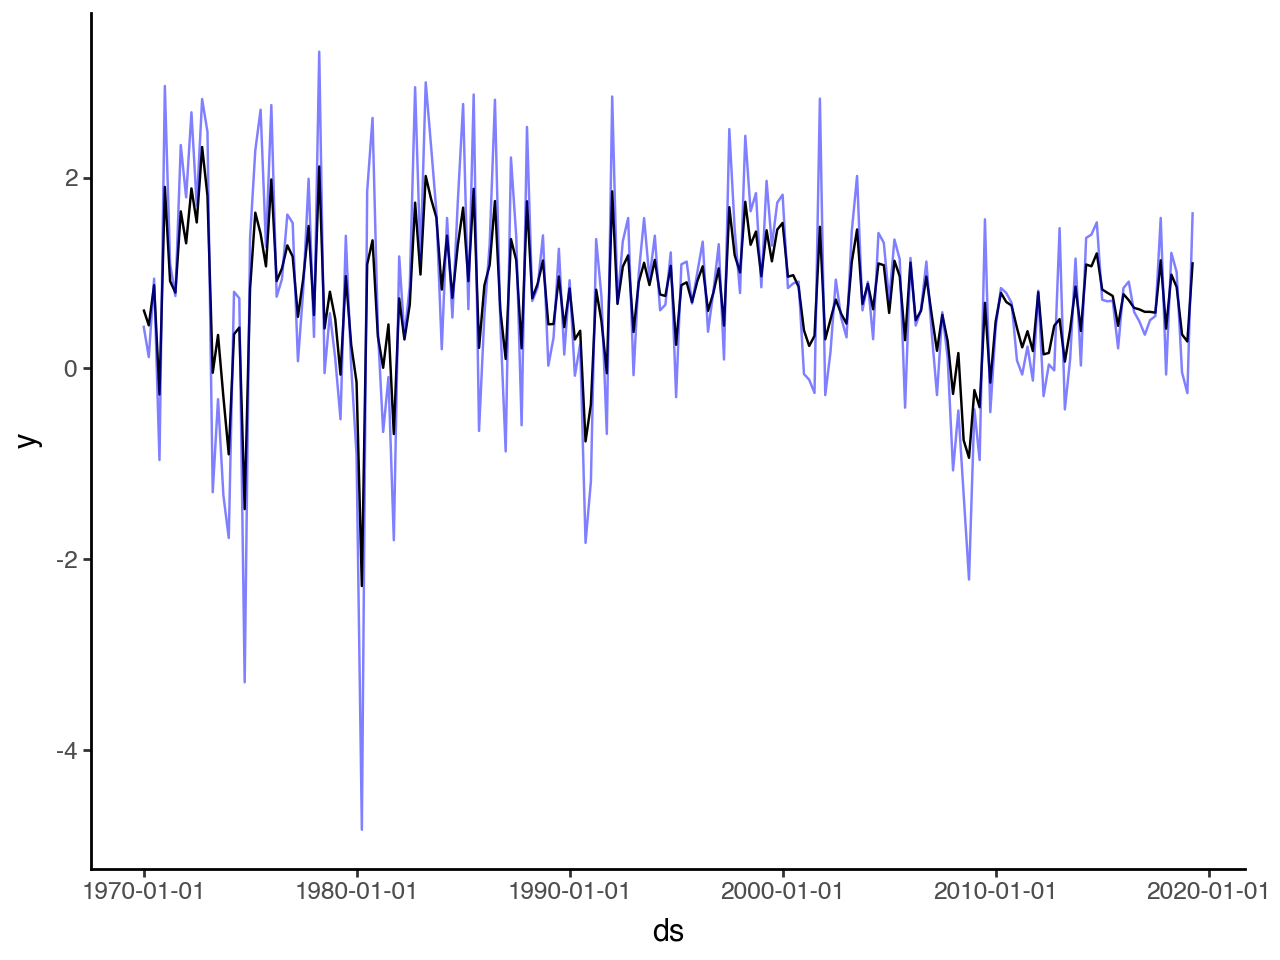

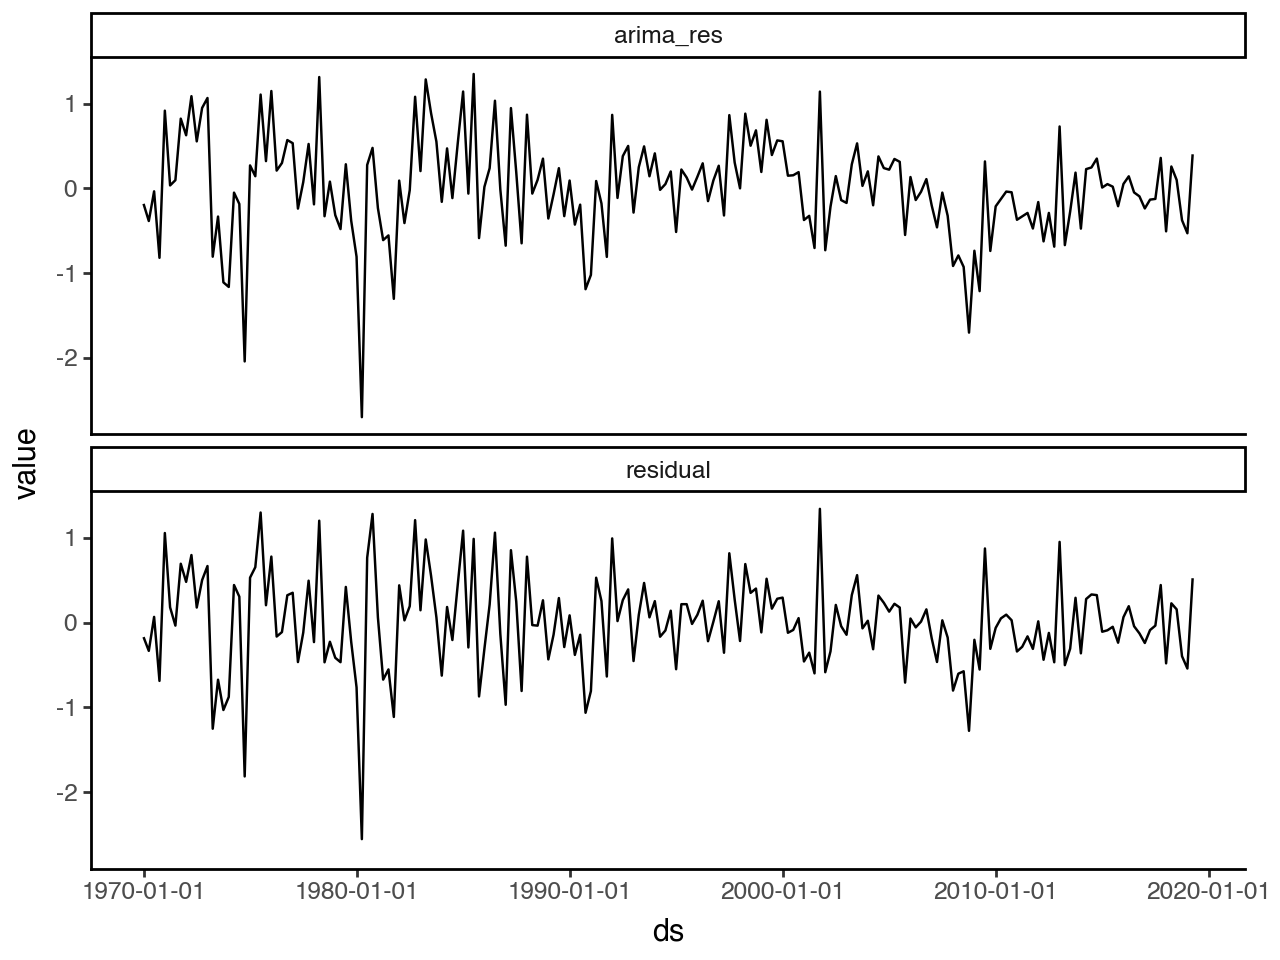

In [30]:
# NOTE: bit confusing, but the innovation residuals are what I would think of as traditional residuals 
df_cons['residual']  = sf.fitted_[0, 0].model_["residuals"]
df_cons['pred_cons'] = df_cons['y'] + df_cons['residual']

# NOTE: although these are called regression residuals, these are really the ARIMA residuals 
df_cons['arima_res'] = (df_cons["y"] - sf.fitted_[0, 0].model_['coef']["ex_1"] * 
                        df_cons["Income"] - coefs["mean"])

# plot residuals
df_cons_long = df_cons[['ds', 'residual', 'arima_res']].melt(id_vars='ds')

(ggplot(data=df_cons, mapping=aes(x='ds', y='y')) + 
 geom_line() + 
 geom_line(mapping=aes(y='pred_cons'), color='blue', alpha=0.5) + 
 theme_classic())

(ggplot(data=df_cons_long, mapping=aes(x='ds', y='value')) + 
 geom_line() + 
 facet_wrap(facets='~variable', ncol=1) + 
 theme_classic())

Ljung-Box     lb_stat  lb_pvalue
1  0.015202   0.901871


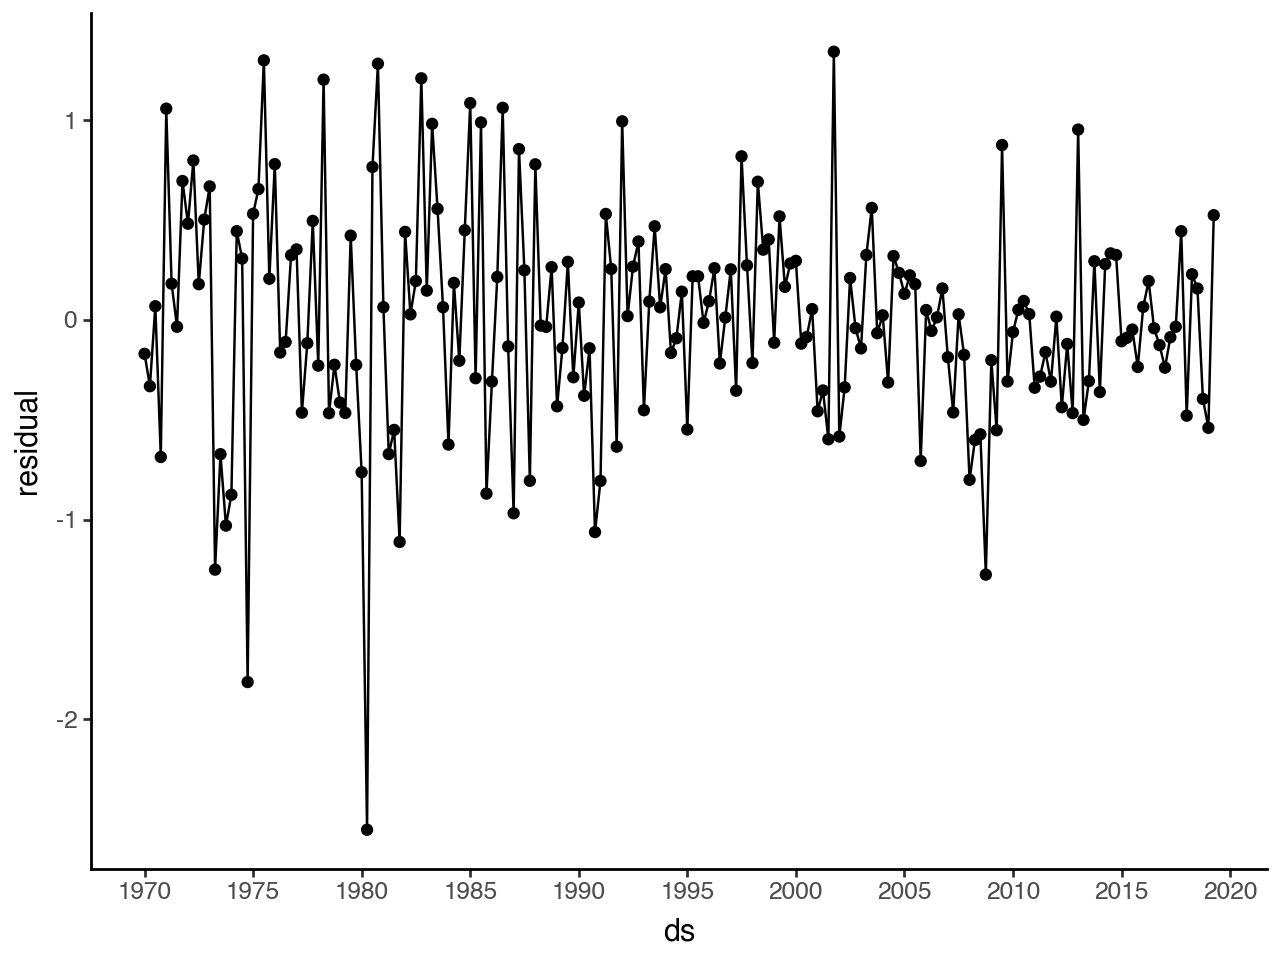

Mean of residuals 0.0017776236572919692


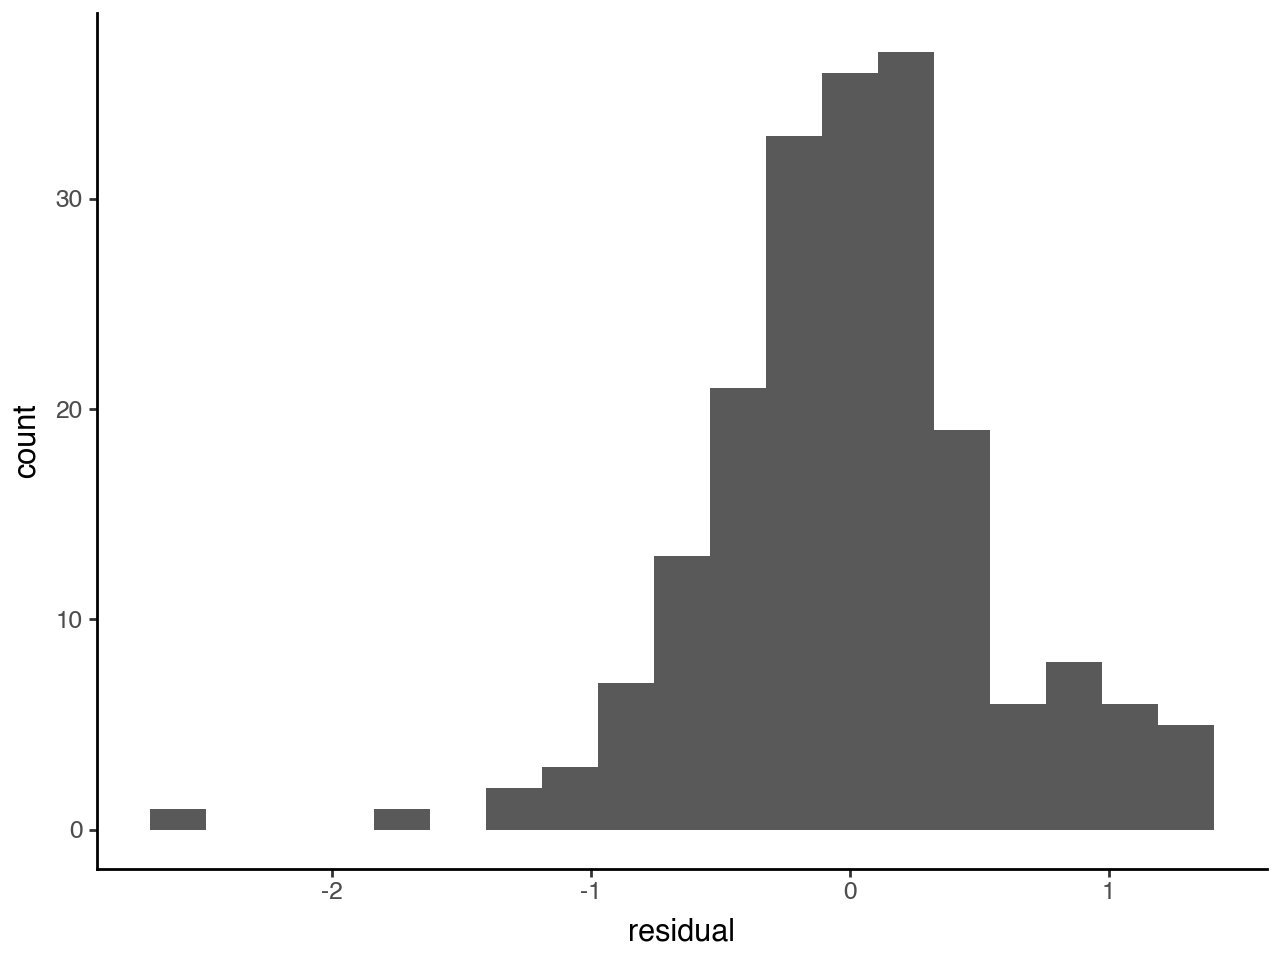

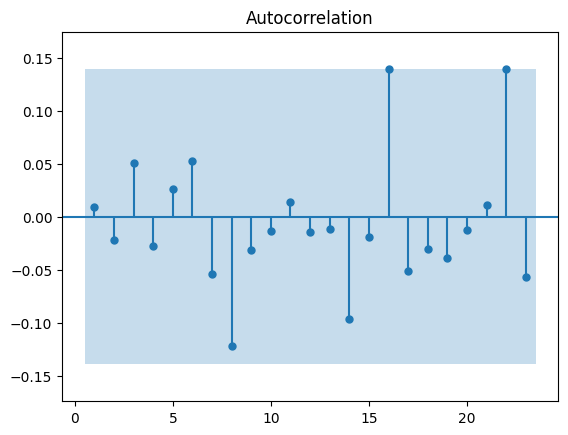

Ljung-Box     lb_stat  lb_pvalue
1  0.015202   0.901871


In [32]:
# investigate residuals 
# NOTE: make sure observations are ordered print Ljung-Box test
print("Ljung-Box", acorr_ljungbox(df_cons['residual'], lags=[1]))

# Plot of residuals over time
(ggplot(data=df_cons, mapping=aes(x='ds', y='residual')) + 
    geom_line() + 
    geom_point() +
    scale_x_datetime(date_breaks='5 years', date_labels='%Y') + 
    theme_classic())

# Histogram
(print("Mean of residuals", df_cons['residual'].mean()))
(ggplot(data=df_cons, mapping=aes(x='residual')) + 
    geom_histogram() + 
    theme_classic())

# ACF plot 
plot_acf(df_cons['residual'], zero=False,
        bartlett_confint=False,
        auto_ylims=True)
from statsmodels.stats.diagnostic import acorr_ljungbox

# print Ljung-Box test
print("Ljung-Box", acorr_ljungbox(df_cons['residual'], lags=[1]))


## 10.3. Forecasting 

## 10.4. Stochastic and deterministic trends

## 10.5. Dynamic harmonic regression

ARIMA and ETS models are designed to handle shorter periods of seasonality such as monthly or quarterly data. For data with frequency greater than monthly occurence, harmonic regression is preferred because seasonal pattern can be modelled using Fourier terms. Several advantages of using Fourier terms: 

1. Handles seasonality of any length 
2. Handles multiple types of seasonality. 
3. Smoothness of seasonal pattern can be controlled by the number of Fourier sin and cos pairs, where lower number results in smoother pattern. 
4. Short-term dynamics are easily handled with simple ARMA erorr. 

Only disadvantage is that seasonality is assumed to be fixed. 

In [46]:
## Australian monthly eating out expenditure 
df_aus_exp = pd.read_csv(filepath_or_buffer='data/raw/aus_retail.csv', parse_dates=['Month'])

df_month = (df_aus_exp
.query('Industry == "Cafes, restaurants and takeaway food services" & Month >= "2004-01-01" & Month <= "2018-12-01"')
  .groupby('Month')
  .agg({'Turnover': 'sum'})
  .assign(unique_id = 'aus_cafe')
  .reset_index()
  .rename(columns={'Month':'ds', 'Turnover':'y'})
  .reindex(columns=['unique_id', 'ds', 'y']))

# examine whether variability increases over time; it does 
# df_month['rolling_std_12'] = df_month['y'].rolling(window=12).std()
# df_month['rolling_std_12']

# create Fourier features 
results = []
for i in range(1,7):
  aus_cafe = df_month.copy()
  aus_cafe['y'] = np.log(aus_cafe['y'])
  features = [partial(fourier, season_length=12, k=i)]

  aus_cafe, future_predictors = pipeline(
    aus_cafe, features=features, freq='MS', h=24)
  
  # create modeler 
  sf = StatsForecast(models=[AutoARIMA(season_length=12, seasonal=False)], freq='MS')

  # compute forecasts 
  res = sf.forecast(df=aus_cafe, h=24, X_df=future_predictors, level=[80, 95])

  # convert to original scale 
  res[res.select_dtypes(include=np.number).columns] = \
      res.select_dtypes(include=np.number).apply(np.exp)
  res['unique_id'] = 'K='+str(i)


  results.append(res)

In [35]:
df_month.head()

,unique_id,ds,y
0,aus_cafe,2004-01-01,1895.1
1,aus_cafe,2004-02-01,1765.7
2,aus_cafe,2004-03-01,1872.8
3,aus_cafe,2004-04-01,1873.7
4,aus_cafe,2004-05-01,1846.0


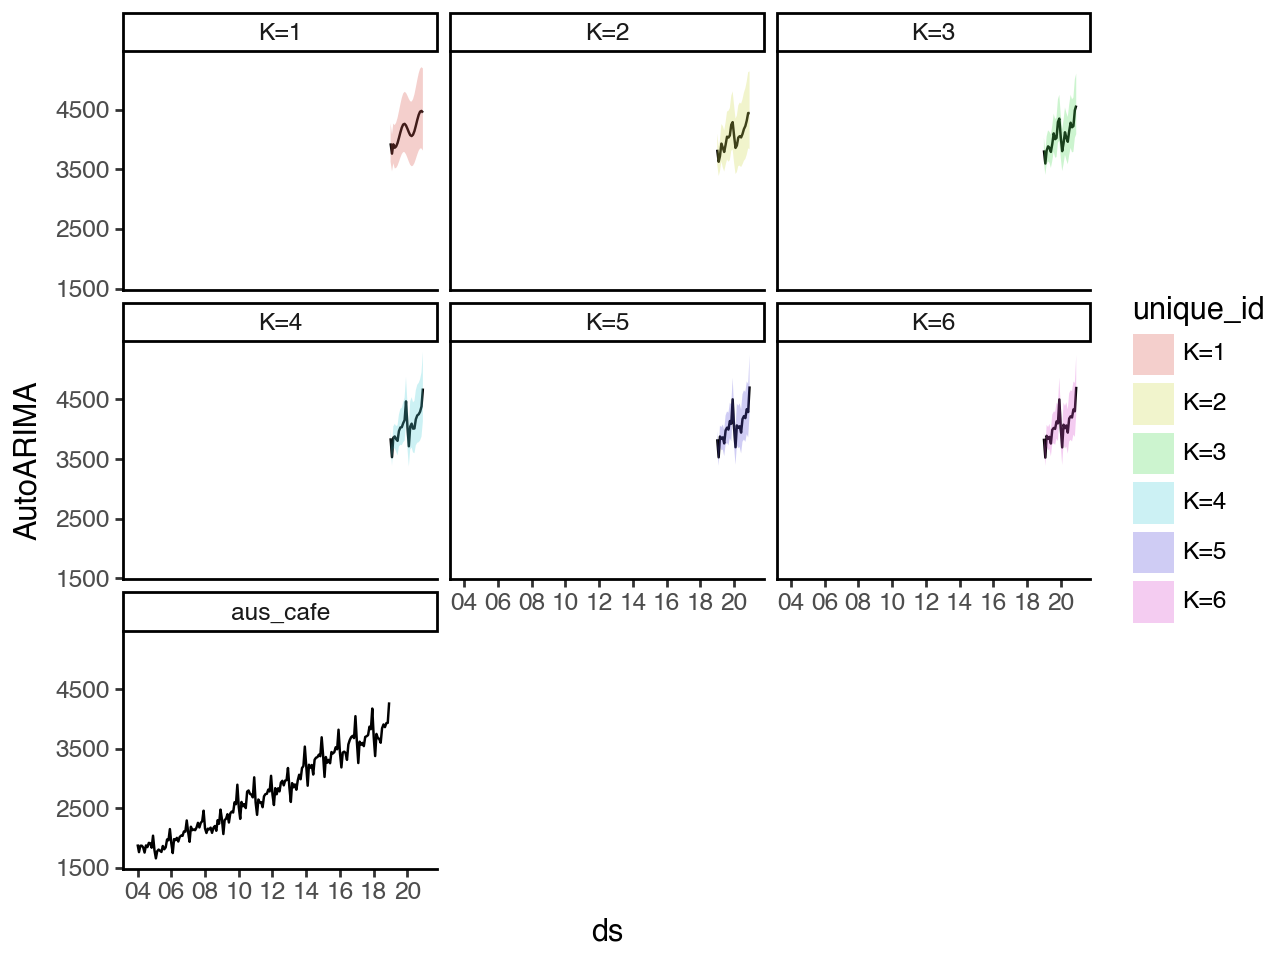

In [43]:
df_result = pd.concat(objs=results, ignore_index=True)

(ggplot(data=df_result, mapping=aes(x='ds', y='AutoARIMA', group='unique_id', fill='unique_id')) + 
 geom_line() + 
 geom_line(inherit_aes=False, data=df_month, 
           mapping=aes(x='ds', y='y')) + 
 scale_x_datetime(date_breaks='2 years', date_labels='%y') + 
 geom_ribbon(mapping=aes(ymin='AutoARIMA-lo-95', ymax='AutoARIMA-hi-95'), alpha=0.3) + 
 facet_wrap(facets='~unique_id') + 
 theme_classic())

## 10.6. Lagged predictors 

In [5]:
## Example: TV advertising and insurance quotations 
# Below analysis determines which lag to be used for number of TV advertisements in predicting number of insurance quotations
df_insur = pd.read_csv('data/raw/insurance.csv', parse_dates=['ds'])
df_insur.head()

# remove first 4 observations 
df_insur["Quotes"][:4] = np.nan

,unique_id,ds,Quotes,TVadverts
0,insurance,2002-01-01,12.97065,7.212725
1,insurance,2002-02-01,15.38714,9.443570
2,insurance,2002-03-01,13.22957,7.534250
3,insurance,2002-04-01,12.97065,7.212725
4,insurance,2002-05-01,15.38714,9.443570


In [12]:
# check if differencing is needed
print("Recommended differencing for quotes", ndiffs(x=df_insur['Quotes'].values))
print("Recommended differencing for TVadverts", ndiffs(x=df_insur['TVadverts'].values))

Recommended differencing for quotes 0
Recommended differencing for TVadverts 0


In [6]:
for lag in [1, 2, 3]:
    df_insur[f"TVadverts_{lag}"] = df_insur["TVadverts"].shift(lag)


sf_models= {}

for lag in [0, 1, 2, 3]:

    model_name = f'sf_lag{lag}'
    sf_models[model_name] = StatsForecast(models=[AutoARIMA(season_length=12, d=0)], freq='MS')

    if lag == 0: 
        vars = ["unique_id", "ds", "Quotes", "TVadverts"]
    else: 
        vars = ["unique_id", "ds", "Quotes", "TVadverts"] + [f'TVadverts_{lag}' for lag in range(1, lag+1)]

    # fit to data 
    _ = sf_models[model_name].fit(df=df_insur[vars], target_col="Quotes")

In [7]:
# try just adding the lag-1 effect
vars = ["unique_id", "ds", "Quotes",  "TVadverts_1"]
sf_models['sf_lag1_only'] = StatsForecast(models=[AutoARIMA(season_length=12, d=0)], freq='MS')
_ = sf_models['sf_lag1_only'].fit(df=df_insur[vars], target_col="Quotes")

# NOTE: lag-1 is the best model 
df_aicc = pd.DataFrame({"name": sf_models.keys()})
df_aicc['aicc'] = np.nan 

# examine AICc values 
for name, model in sf_models.items(): 
    df_aicc.loc[df_aicc['name'].eq(name), 'aicc'] = model.fitted_[0][0].model_["aicc"]
df_aicc

,name,aicc
0,sf_lag0,66.672679
1,sf_lag1,58.430993
2,sf_lag2,61.525189
3,sf_lag3,64.707415
4,sf_lag1_only,144.277880


In [14]:
sf = StatsForecast(models=[AutoARIMA(season_length=1, d=0)], freq='MS')

_ = sf.fit(df=df_insur[["unique_id", "ds", "Quotes", "TVadverts", "TVadverts_1"]].dropna(),
       target_col="Quotes")

print(ARIMASummary(sf.fitted_[0, 0].model_))
# sf.fitted_[0, 0].model_['coef']["mean"] = sf.fitted_[0, 0].model_['coef'].pop("intercept")
print(f"Coefficients: {sf.fitted_[0, 0].model_['coef']}")
print(f"sigma^2     : {sf.fitted_[0, 0].model_['sigma2']:.2f}")
print(f"loglik      : {sf.fitted_[0, 0].model_['loglik']:.2f}")
print(f"aic         : {sf.fitted_[0, 0].model_['aic']:.2f}")
print(f"aicc        : {sf.fitted_[0, 0].model_['aicc']:.2f}")
print(f"bic         : {sf.fitted_[0, 0].model_['bic']:.2f}")

Regression with ARIMA(1,0,1) errors
Coefficients: {'ar1': np.float64(0.6596697768739646), 'ma1': np.float64(0.6713689546787954), 'ex_1': np.float64(1.3946676557148865), 'ex_2': np.float64(0.25258774353945523)}
sigma^2     : 0.22
loglik      : -22.68
aic         : 55.37
aicc        : 57.37
bic         : 63.28


Model Toronto gas prices using 

1. ETS model  
2. SARIMA model 
3. Dynamic regression  
4. Dynamic harmonic regression 